🎬 Memulai Pelatihan RL: Mode Generalisasi Multi-Trace (.log/.txt)
✅ Berhasil memuat 8 file trace.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 100       |
|    ep_rew_mean     | -2.33e+03 |
| time/              |           |
|    fps             | 5384      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -1.66e+03   |
| time/                   |             |
|    fps                  | 4101        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.01003849

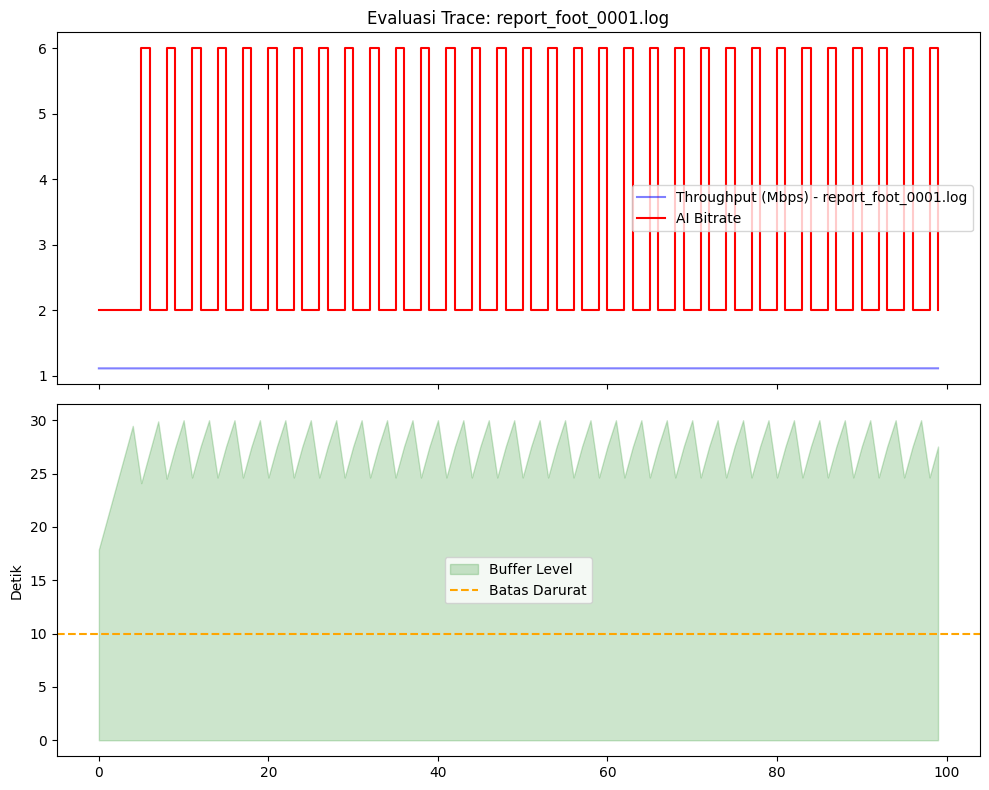

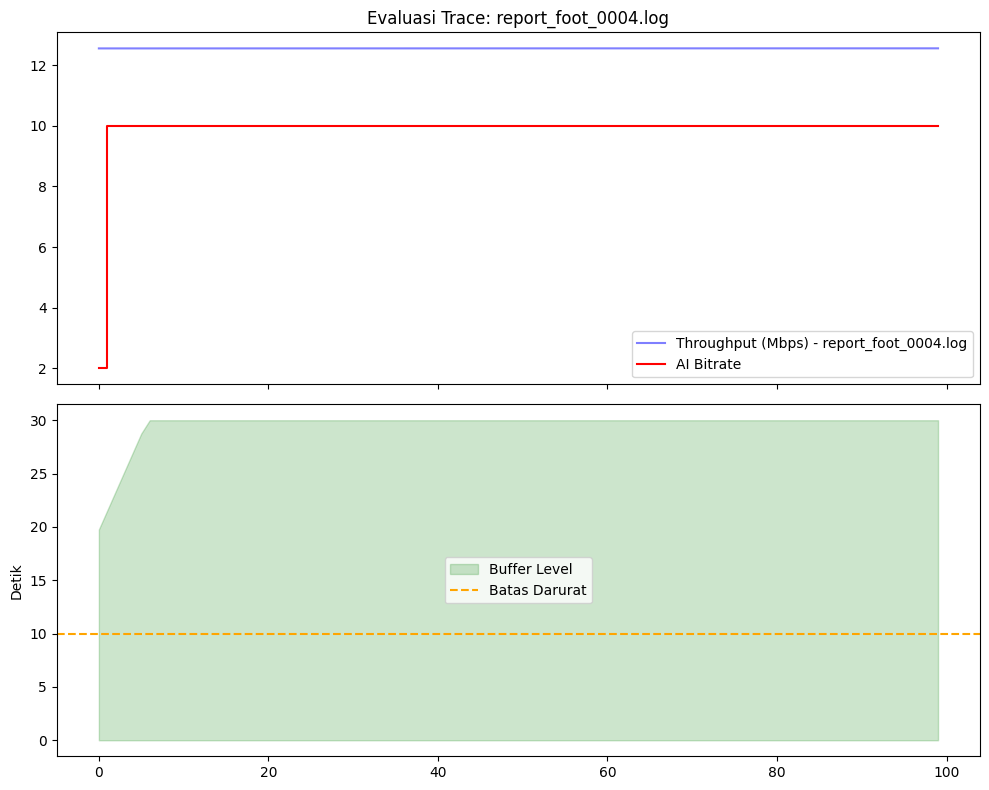

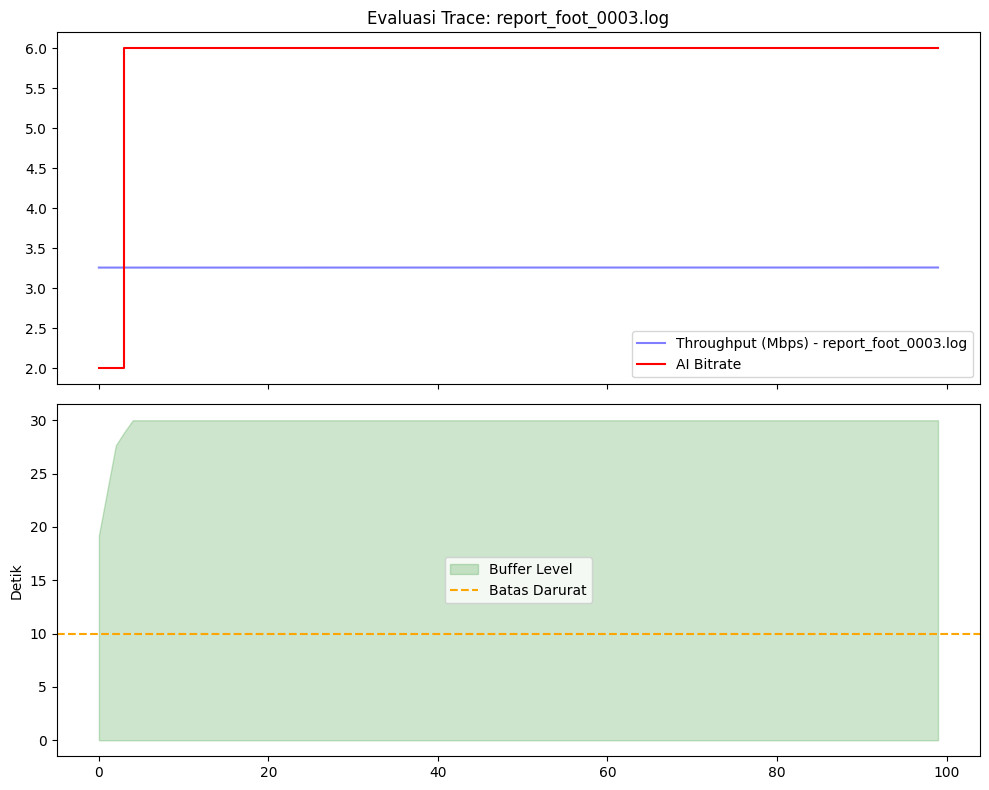

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
import os
import random

class MahimahiTraceManager:
    """
    Mengelola banyak file bandwidth dari sebuah folder (.txt atau .log).
    Sistem akan memilih satu trace secara acak setiap kali episode di-reset.
    Disertai normalisasi otomatis untuk skala Mahimahi.
    """
    def __init__(self, folder_path="traces_folder"):
        self.traces = []
        
        # Cek folder dan muat semua file .txt atau .log
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.endswith('.txt') or f.endswith('.log')]
            for file in files:
                path = os.path.join(folder_path, file)
                try:
                    with open(path, 'r') as f:
                        # Mahimahi format: seringkali berupa bytes atau milidetik
                        # Kita lakukan pembersihan data kosong
                        raw_data = [float(line.strip()) for line in f if line.strip()]
                        
                        if raw_data:
                            # NORMALISASI: Jika angka terlalu besar (seperti 175.000), 
                            # kita asumsikan itu bytes/unit dan konversi ke skala Mbps (0.5 - 20)
                            max_val = max(raw_data)
                            scale_factor = 1.0
                            if max_val > 1000:
                                # Skala otomatis: menyesuaikan agar max_val berada di kisaran 15-20 Mbps
                                scale_factor = 15.0 / max_val
                            
                            normalized_data = [d * scale_factor for d in raw_data]
                            
                            self.traces.append({
                                "name": file,
                                "data": normalized_data,
                                "raw_max": max_val
                            })
                except Exception as e:
                    print(f"⚠️ Gagal membaca {file}: {e}")
            
            if self.traces:
                print(f"✅ Berhasil memuat {len(self.traces)} file trace.")
        
        if not self.traces:
            print("⚠️ Folder trace kosong. Menggunakan pola sintetis...")
            self.traces.append({
                "name": "synth_volatile",
                "data": np.clip(10 + 5 * np.sin(np.linspace(0, 50, 1000)) + np.random.normal(0, 2, 1000), 0.5, 20).tolist()
            })

        self.active_trace = None
        self.ptr = 0

    def select_random_trace(self):
        self.active_trace = random.choice(self.traces)
        # Mulai dari titik acak agar agen tidak menghafal urutan yang sama terus menerus
        if len(self.active_trace["data"]) > 105:
            self.ptr = random.randint(0, len(self.active_trace["data"]) - 105)
        else:
            self.ptr = 0
        return self.active_trace["name"]

    def get_next_bandwidth(self):
        if not self.active_trace:
            self.select_random_trace()
        
        val = self.active_trace["data"][self.ptr]
        self.ptr = (self.ptr + 1) % len(self.active_trace["data"])
        return val

class TandonMahimahiEnv(gym.Env):
    """
    World Agent (Lingkungan) berbasis Multi-Trace Mahimahi.
    Logic: Operator Tandon Air (Safety First).
    """
    def __init__(self, trace_manager):
        super(TandonMahimahiEnv, self).__init__()
        self.trace_manager = trace_manager
        self.bitrates = [0.5, 2.5, 8.0] # Mbps
        
        # State Space (7 Variabel):
        # [Buffer, Throughput, LastAction, Buffer_Trend, TP_Trend, RTT, Dropped]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, -5, -5, 0, 0]),
            high=np.array([30, 20, 2, 5, 5, 1000, 100]),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)
        
        self.state = None
        self.max_steps = 100
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        trace_name = self.trace_manager.select_random_trace()
        initial_tp = self.trace_manager.get_next_bandwidth()
        
        # Mulai dengan buffer 15s untuk stabilitas awal
        self.state = np.array([15.0, initial_tp, 1.0, 0.0, 0.0, 40.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {"trace": trace_name}

    def step(self, action):
        buffer, last_tp_avg, last_action, _, _, rtt, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        raw_tp = self.trace_manager.get_next_bandwidth()
        
        # Simulasi Tandon
        seg_duration = 5.0
        # Waktu download nyata (kunci pembelajaran agen)
        download_time = (chosen_bitrate * seg_duration / (raw_tp + 0.1)) + (rtt / 1000.0)
        stalling = max(0, download_time - buffer)
        
        new_buffer = max(0, buffer - download_time) + seg_duration
        new_buffer = min(new_buffer, 30.0)
        
        buf_trend = np.clip(new_buffer - buffer, -5, 5)
        tp_trend = np.clip(raw_tp - last_tp_avg, -5, 5)
        
        # --- REWARD LOGIC (Tandon Air) ---
        reward = chosen_bitrate * 1.0
        reward -= abs(action - last_action) * 0.8 # Penalti gonta-ganti kualitas
        
        if stalling > 0:
            reward -= 150.0 # Penalti macet diperberat agar agen sangat takut
        
        if new_buffer < 10.0:
            reward -= 20.0 # Penalti masuk zona darurat
            if action == 2: # Jika nekat HIGH saat buffer kritis
                reward -= 50.0
            
        if action == 0 and raw_tp > 10.0 and new_buffer > 20.0:
            reward -= 15.0 # Penalti terlalu penakut (pelit)

        self.state = np.array([new_buffer, raw_tp, float(action), buf_trend, tp_trend, 40.0, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {"raw_tp": raw_tp}

def run_multi_trace_training():
    print("🎬 Memulai Pelatihan RL: Mode Generalisasi Multi-Trace (.log/.txt)")
    
    tm = MahimahiTraceManager(folder_path="traces/mahimahi") 
    env = TandonMahimahiEnv(tm)
    
    # Optimasi Hyperparameters untuk data bervariasi
    model = PPO("MlpPolicy", env, verbose=1, 
                learning_rate=0.0003, 
                n_steps=2048, # Batch lebih besar agar belajar dari banyak variasi sekaligus
                batch_size=128,
                ent_coef=0.02) # Entropi lebih tinggi agar agen rajin eksplorasi
    
    # Latih lebih lama karena variasi trace banyak
    model.learn(total_timesteps=200000)
    model.save("ndn_video_brain_tandon_multi_trace")
    print("✅ Model 'ndn_video_brain_tandon_multi_trace.zip' telah diperbarui.")

    # --- EVALUASI ---
    for i in range(3): # Tes pada 3 file trace acak
        obs, info = env.reset()
        name = info["trace"]
        history = []
        for _ in range(100):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info_step = env.step(action)
            history.append({'S': info_step['raw_tp'], 'B': obs[0], 'A': action})
        
        df = pd.DataFrame(history)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
        ax1.plot(df.index, df['S'], label=f'Throughput (Mbps) - {name}', color='blue', alpha=0.5)
        ax1.step(df.index, df['A']*4 + 2, label='AI Bitrate', color='red', where='post')
        ax1.set_title(f"Evaluasi Trace: {name}")
        ax1.legend()
        
        ax2.fill_between(df.index, df['B'], color='green', alpha=0.2, label='Buffer Level')
        ax2.axhline(y=10, color='orange', linestyle='--', label='Batas Darurat')
        ax2.set_ylabel("Detik")
        ax2.legend()
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    run_multi_trace_training()